# Synthèse — contagion SIS ↔ E_i (notebook propre)

Reprise propre de l'analyse, appuyée sur le package `code/` (détection, fits SIS, balayage B/R, tout en cache `cache/`). Plan :

1. **Clustering par période** — seuil scale-free (ρc choisi pour une distribution des degrés en loi de puissance), clustering moyen par période de crise.
2. **Signaux réseau** — λ_max/⟨λ⟩ (normalisé), ⟨|C_ij|⟩, ⟨r⟩, avec les montées de crise (détection `monthly_correlations` : pics de ⟨|C|⟩).
3. **Balayage (B, R)** — méthode des pics ; augmenter B et R sélectionne-t-il les mêmes actifs qu'à B=R=1 ?
4. **Test null** — fit SIS sur une montée individuelle de l'actif **hors** crise collective : le SIS ne marche-t-il que sur les crises collectives ?
5. **Tableau** — nb d'actifs retenus par méthode × période + % d'actifs communs à toutes les méthodes.
6. **Communautés** — par période de crise : graphe + Louvain, les actifs en crise sont-ils dans une même communauté ?

In [1]:
import sys, warnings
sys.path.insert(0, 'code')
import numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from scipy.stats import linregress
from data import build_context
import pipeline, periods, selection, sis, config

# Contexte partagé (données + matrices A + caches base/crisis_map/...)
ctx = build_context()
P  = pipeline.load_periods(ctx)                 # intervals_chrono, crisis_map
PK = pipeline.fit_peaks(ctx, P['crisis_map'])   # peak_rises (montées), peak_pd (fits SIS)
SP = pipeline.spectral(ctx)                     # diag : λ_max/⟨λ⟩, ⟨|C|⟩, ⟨r⟩

peak_rises = PK['peak_rises']                   # 17 montées creux→sommet
peak_pd    = PK['peak_pd']                      # (cache, fits) par montée
crisis_map = P['crisis_map']
diag       = SP['diag']
all_days   = pd.to_datetime(ctx.all_days)
arr        = ctx.data.values
N          = ctx.N
print(f'{N} actifs, {len(all_days)} jours, {len(peak_rises)} montées de crise')

N = 146 actifs, T = 13360 obs ; 2019-04-01 10:00:00 -> 2023-05-03 15:30:00
[cache] OK  base
1031 jours ; <|C_ij|> moyen = 0.4686
[cache] OK  crisis_map
[cache] OK  peak_period_data
[cache] OK  spectral_diag
146 actifs, 1031 jours, 17 montées de crise


## 1. Clustering par période 

Pour chaque fenêtre on choisit le seuil **ρc** minimal rendant la distribution des degrés **convexe** (proxy loi de puissance / scale-free), puis on mesure le **clustering moyen pondéré** du graphe seuillé. On calcule :
- la **courbe** de clustering dans le temps (fenêtres 2 jours, lissage 23, comme `article.ipynb`) ;
- par **période de crise** (montées de pics) : ρc, le clustering sur la matrice de la période, et le **minimum** du clustering dans la fenêtre.

In [2]:
def scale_free_threshold(C, start=0.8, step=0.05, cap=0.95):
    """Seuil ρc minimal rendant la distribution des degrés convexe (Achitouv)."""
    rc = start
    while rc <= cap:
        A = (np.abs(C) >= rc).astype(int); np.fill_diagonal(A, 0); deg = A.sum(1)
        counts = np.bincount(deg, minlength=int(deg.max()) + 1).astype(float)
        kmax = int(np.quantile(deg, 0.9))
        if (kmax < 2) or np.all(np.diff(counts[:kmax + 1], 2) >= 0):
            return rc
        rc = round(rc + step, 2)
    return cap

def clustering_at_sft(C):
    """(ρc, clustering moyen pondéré) du graphe seuillé au seuil scale-free."""
    rc = scale_free_threshold(C)
    Wt = np.abs(C) * (np.abs(C) >= rc); np.fill_diagonal(Wt, 0.0)
    return rc, nx.average_clustering(nx.from_numpy_array(Wt), weight='weight')

# Courbe de clustering : fenêtres 2 jours ouvrés (26 obs), lissage 23 (Achitouv)
SHORT = 2 * 13
idx = ctx.data.index
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    clus, cdates = [], []
    for i in range(len(arr) // SHORT):
        sub = arr[i * SHORT:(i + 1) * SHORT]
        _, cl = clustering_at_sft(np.nan_to_num(np.corrcoef(sub.T)))
        clus.append(cl); cdates.append(idx[(i + 1) * SHORT - 1])
clus = np.array(clus); cdates = pd.to_datetime(cdates)
clus_s = pd.Series(clus).rolling(23, center=True, min_periods=1).mean().values
print(f'courbe clustering : {len(clus)} fenêtres de 2 jours')

courbe clustering : 513 fenêtres de 2 jours


,debut,fin,n_crise,rho_c,clust_periode,clust_min_fenetre
0,2019-04-01,2019-05-15,73,0.80,0.0296,0.0666
1,2019-07-22,2019-08-14,38,0.80,0.0874,0.0475
2,2019-11-19,2020-02-04,19,0.80,0.0204,0.0485
3,2020-02-11,2020-03-06,139,0.90,0.0660,0.0867
4,2020-05-29,2020-06-16,94,0.90,0.0578,0.0786
5,2020-08-24,2020-09-14,5,0.80,0.0756,0.0599
6,2020-10-19,2020-11-04,25,0.80,0.1321,0.0646
7,2020-12-10,2021-03-04,6,0.80,0.0385,0.0572
8,2021-03-29,2021-05-13,8,0.80,0.0110,0.0548
9,2021-08-05,2021-09-29,37,0.80,0.0784,0.0724


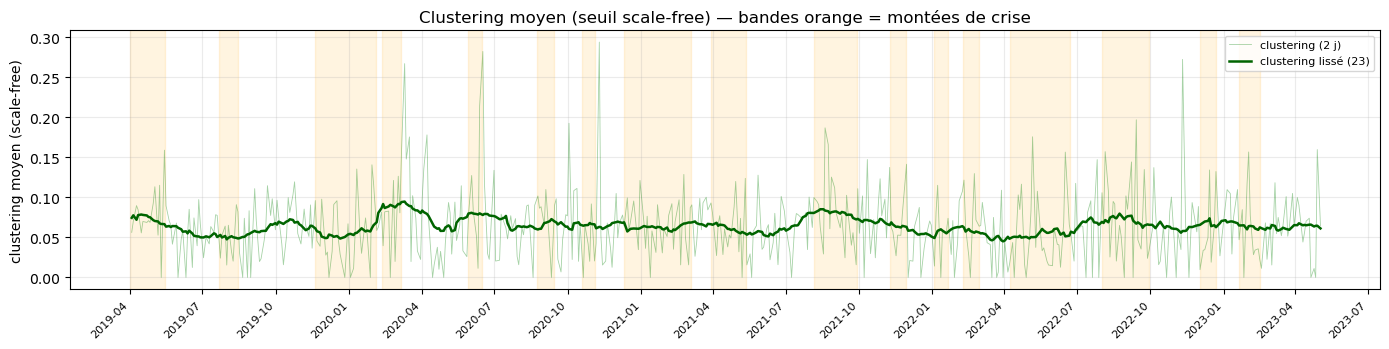

In [3]:
# Tableau par période de crise (montée)
rows = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for (pa, pb) in peak_rises:
        d0, d1 = all_days[pa], all_days[pb]
        obs = (idx >= d0) & (idx <= d1)
        rc, clp = clustering_at_sft(np.nan_to_num(np.corrcoef(arr[np.asarray(obs)].T)))
        inwin = (cdates >= d0) & (cdates <= d1)
        cmin = clus_s[inwin].min() if inwin.any() else np.nan
        rows.append({'debut': str(d0)[:10], 'fin': str(d1)[:10],
                     'n_crise': len(peak_pd[(pa, pb)][0]), 'rho_c': rc,
                     'clust_periode': round(clp, 4), 'clust_min_fenetre': round(cmin, 4)})
clust_table = pd.DataFrame(rows)
display(clust_table)

# Courbe de clustering avec bandes de crise
fig, ax = plt.subplots(figsize=(14, 3.6))
ax.plot(cdates, clus, color='green', lw=0.6, alpha=0.35, label='clustering (2 j)')
ax.plot(cdates, clus_s, color='darkgreen', lw=1.8, label='clustering lissé (23)')
for (pa, pb) in peak_rises:
    ax.axvspan(all_days[pa], all_days[pb], color='orange', alpha=0.12)
ax.set_ylabel('clustering moyen (scale-free)'); ax.grid(alpha=0.25); ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_title('Clustering moyen (seuil scale-free) — bandes orange = montées de crise')
plt.tight_layout(); plt.show()

### Distributions associées

Pour juger le seuil scale-free et le clustering : distribution des **degrés** (crise COVID vs fenêtre calme) en linéaire et log-log, histogramme du **clustering** sur toutes les fenêtres, et distribution des **corrélations** C_ij (la vraie signature de crise).

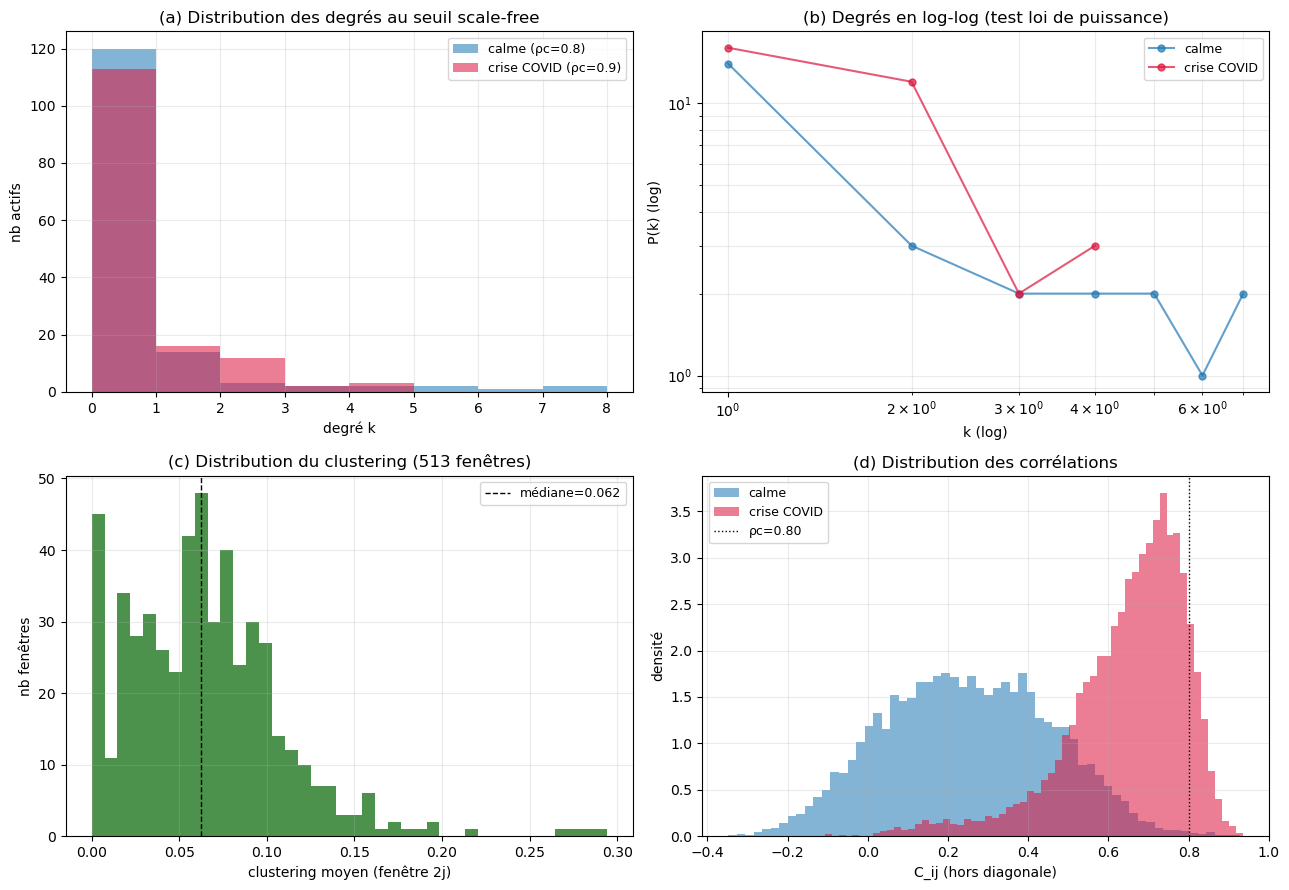

In [4]:
# Distributions associees : degres (crise vs calme), clustering, correlations
def _corr_window(d0, d1):
    obs = (idx >= d0) & (idx <= d1)
    return np.nan_to_num(np.corrcoef(arr[np.asarray(obs)].T))

def _degrees(C, rc):
    A = (np.abs(C) >= rc).astype(int); np.fill_diagonal(A, 0); return A.sum(1)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    C_crise = _corr_window(all_days[peak_rises[3][0]], all_days[peak_rises[3][1]])  # COVID
    C_calme = _corr_window(pd.Timestamp('2021-06-15'), pd.Timestamp('2021-07-25'))  # hors bande
rc_cr, rc_ca = scale_free_threshold(C_crise), scale_free_threshold(C_calme)
d_cr, d_ca = _degrees(C_crise, rc_cr), _degrees(C_calme, rc_ca)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
ax = axes[0, 0]
bins = np.arange(0, max(d_cr.max(), d_ca.max()) + 2)
ax.hist(d_ca, bins=bins, alpha=0.55, color='tab:blue', label=f'calme (ρc={rc_ca})')
ax.hist(d_cr, bins=bins, alpha=0.55, color='crimson', label=f'crise COVID (ρc={rc_cr})')
ax.set_xlabel('degré k'); ax.set_ylabel('nb actifs'); ax.legend(fontsize=9); ax.grid(alpha=0.25)
ax.set_title('(a) Distribution des degrés au seuil scale-free')

ax = axes[0, 1]
for d, c, lab in [(d_ca, 'tab:blue', 'calme'), (d_cr, 'crimson', 'crise COVID')]:
    cnt = np.bincount(d); k = np.nonzero(cnt)[0]; k = k[k > 0]
    ax.loglog(k, cnt[k], 'o-', color=c, alpha=0.7, ms=5, label=lab)
ax.set_xlabel('k (log)'); ax.set_ylabel('P(k) (log)'); ax.legend(fontsize=9); ax.grid(alpha=0.25, which='both')
ax.set_title('(b) Degrés en log-log (test loi de puissance)')

ax = axes[1, 0]
ax.hist(clus, bins=40, color='darkgreen', alpha=0.7)
ax.axvline(np.median(clus), color='k', ls='--', lw=1, label=f'médiane={np.median(clus):.3f}')
ax.set_xlabel('clustering moyen (fenêtre 2j)'); ax.set_ylabel('nb fenêtres')
ax.legend(fontsize=9); ax.grid(alpha=0.25)
ax.set_title(f'(c) Distribution du clustering ({len(clus)} fenêtres)')

ax = axes[1, 1]
iu = np.triu_indices_from(C_crise, k=1)
ax.hist(C_calme[iu], bins=60, density=True, alpha=0.55, color='tab:blue', label='calme')
ax.hist(C_crise[iu], bins=60, density=True, alpha=0.55, color='crimson', label='crise COVID')
ax.axvline(0.8, color='k', ls=':', lw=1, label='ρc=0.80')
ax.set_xlabel('C_ij (hors diagonale)'); ax.set_ylabel('densité'); ax.legend(fontsize=9); ax.grid(alpha=0.25)
ax.set_title('(d) Distribution des corrélations')
plt.tight_layout(); plt.show()

#### Degré vs rang

Degrés triés par ordre décroissant tracés contre leur rang (rank plot, façon Zipf). En log-log, une **droite** = loi de puissance ; une décroissance brutale puis un plateau = peu de hubs et une masse d'actifs faiblement connectés.

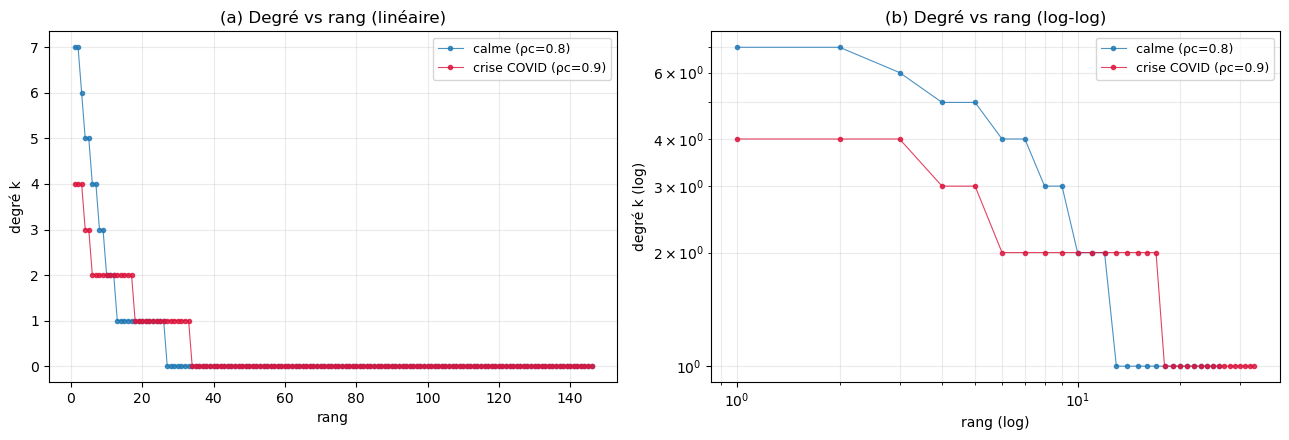

In [5]:
# Degré vs rang (rank plot, log-log) : test loi de puissance
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.5))
for d, c, lab, rc in [(d_ca, 'tab:blue', 'calme', rc_ca), (d_cr, 'crimson', 'crise COVID', rc_cr)]:
    ds = np.sort(d)[::-1]
    rank = np.arange(1, len(ds) + 1)
    axL.plot(rank, ds, 'o-', color=c, ms=3, lw=0.8, alpha=0.8, label=f'{lab} (ρc={rc})')
    m = ds > 0
    axR.loglog(rank[m], ds[m], 'o-', color=c, ms=3, lw=0.8, alpha=0.8, label=f'{lab} (ρc={rc})')
axL.set_xlabel('rang'); axL.set_ylabel('degré k'); axL.set_title('(a) Degré vs rang (linéaire)')
axL.grid(alpha=0.25); axL.legend(fontsize=9)
axR.set_xlabel('rang (log)'); axR.set_ylabel('degré k (log)'); axR.set_title('(b) Degré vs rang (log-log)')
axR.grid(alpha=0.25, which='both'); axR.legend(fontsize=9)
plt.tight_layout(); plt.show()

#### Degré vs rang par période

Un rank plot log-log par montée de crise (17 panneaux). Permet de voir si la « scale-free-ité » du réseau seuillé varie d'une crise à l'autre.

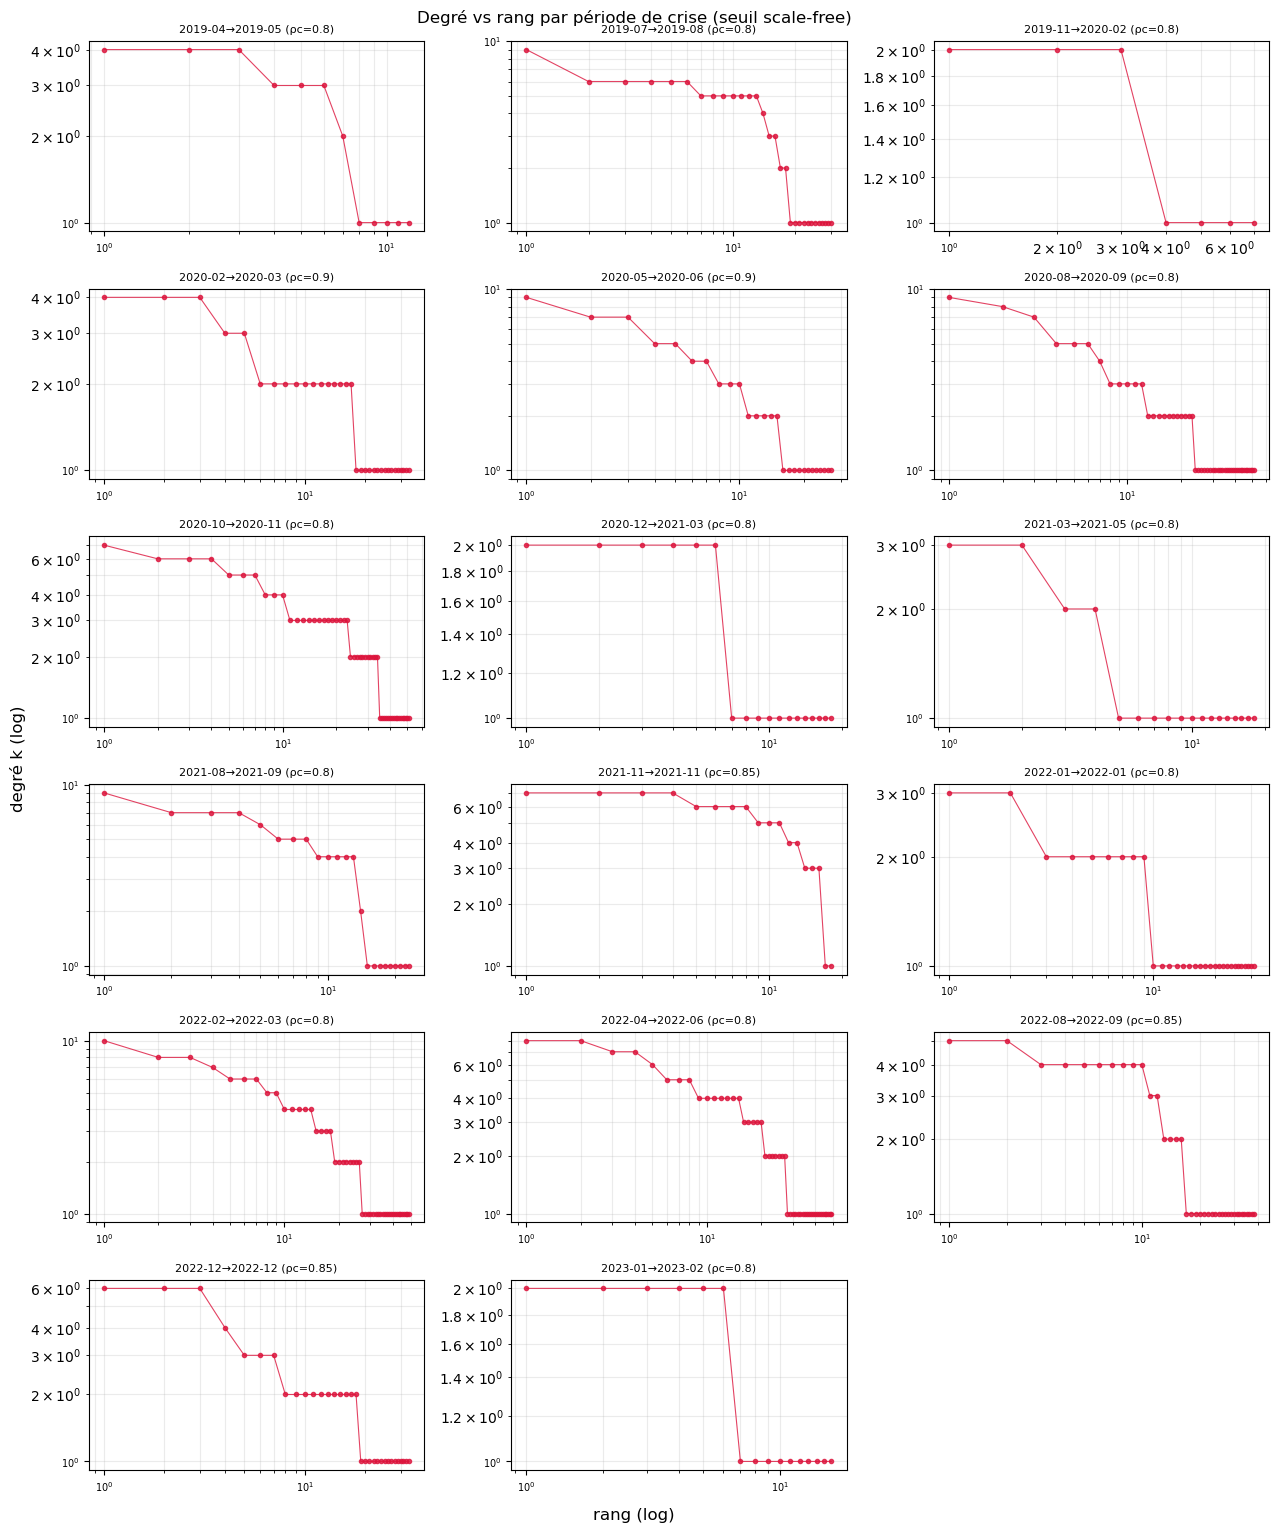

In [6]:
# Degré vs rang (log-log) — un panneau par période de crise (montée)
n = len(peak_rises); ncol = 3; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 2.6 * nrow))
axes = axes.ravel()
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for j, (pa, pb) in enumerate(peak_rises):
        d0, d1 = all_days[pa], all_days[pb]
        C = _corr_window(d0, d1); rc = scale_free_threshold(C)
        d = _degrees(C, rc); ds = np.sort(d)[::-1]
        rank = np.arange(1, len(ds) + 1); m = ds > 0
        ax = axes[j]
        ax.loglog(rank[m], ds[m], 'o-', color='crimson', ms=3, lw=0.8, alpha=0.8)
        ax.set_title(f'{str(d0)[:7]}→{str(d1)[:7]} (ρc={rc})', fontsize=8)
        ax.grid(alpha=0.25, which='both'); ax.tick_params(labelsize=7)
for k in range(n, len(axes)):
    axes[k].axis('off')
fig.supxlabel('rang (log)'); fig.supylabel('degré k (log)')
fig.suptitle('Degré vs rang par période de crise (seuil scale-free)', fontsize=12)
plt.tight_layout(); plt.show()

#### Convexité de P(k) par période

C'est *cette* distribution (P(k) = nb d'actifs de degré k) que le seuil scale-free rend convexe : on monte ρc tant que la dérivée seconde de P(k) sur **[0, kmax]** (kmax = 90ᵉ percentile des degrés, ligne pointillée) n'est pas ≥ 0. La portion **rouge** = zone effectivement testée. Quand kmax < 2 le test est trivial → ρc reste à 0.80.

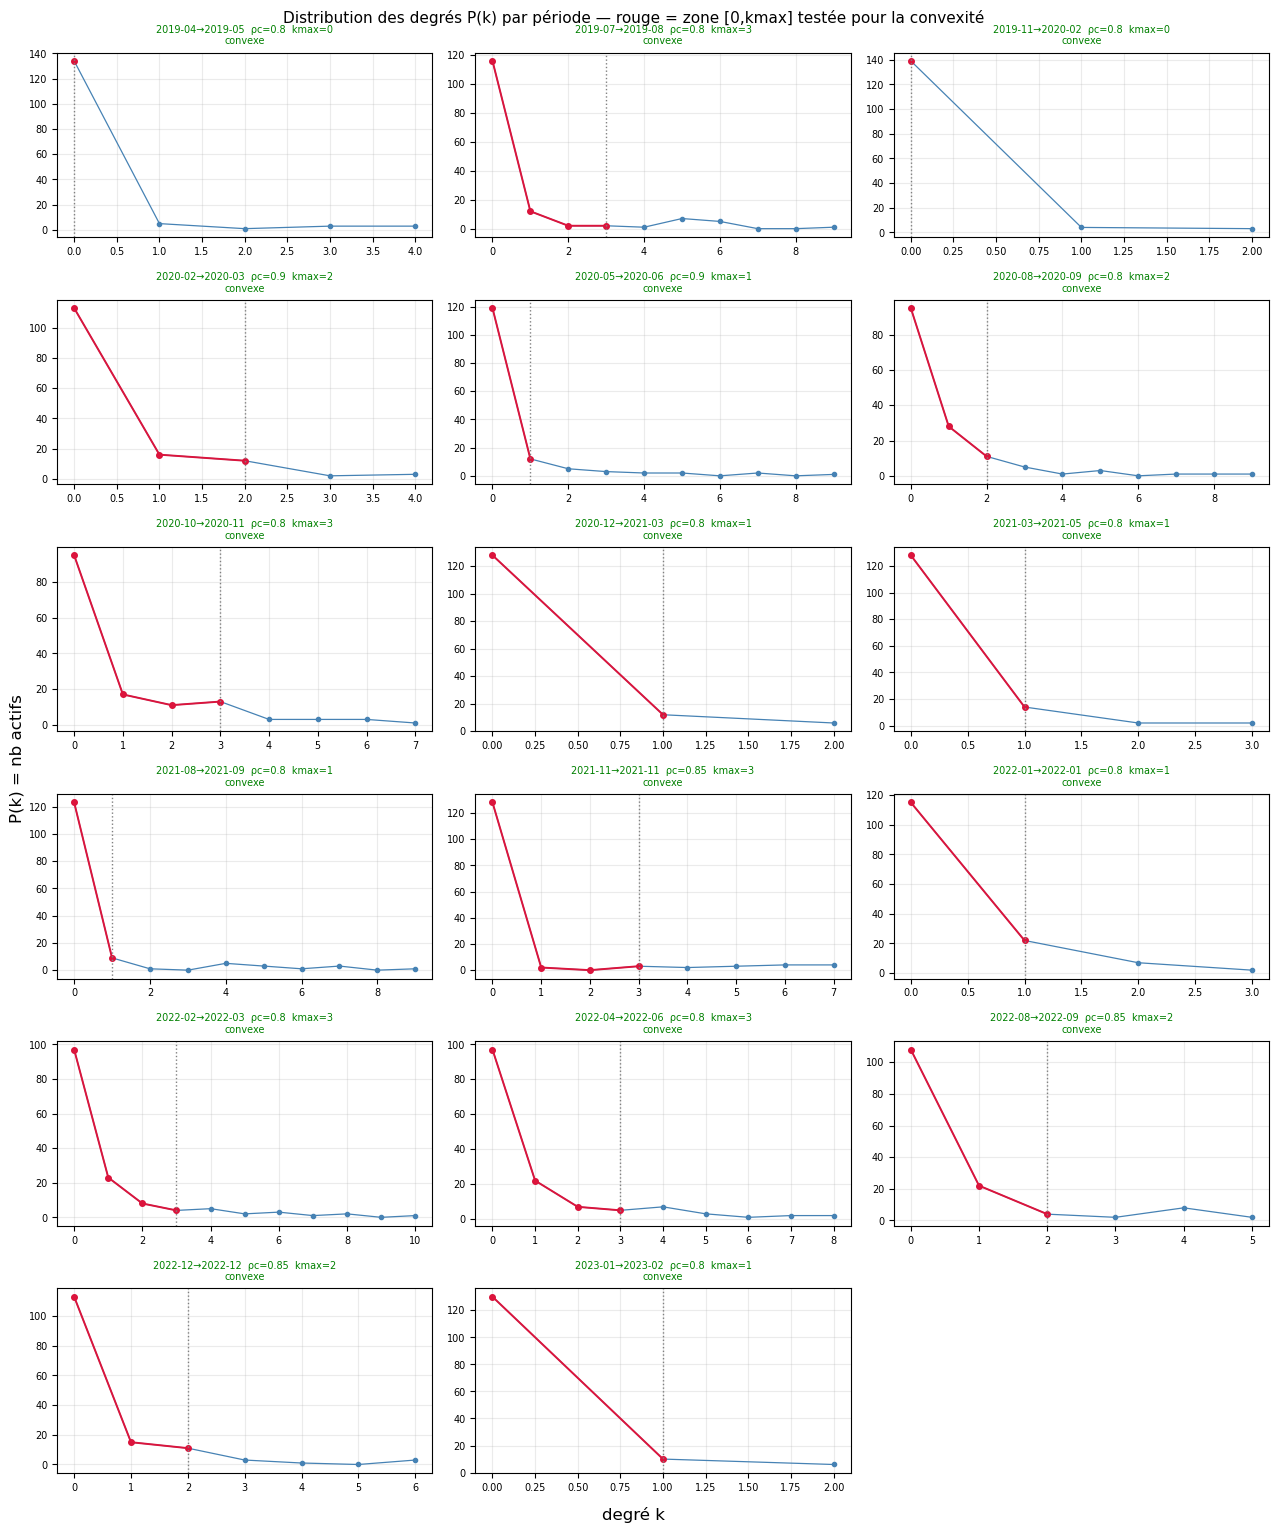

In [7]:
# Distribution des degrés P(k) par période — l'objet rendu convexe par le seuil (Achitouv)
n = len(peak_rises); ncol = 3; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 2.6 * nrow)); axes = axes.ravel()
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for j, (pa, pb) in enumerate(peak_rises):
        d0, d1 = all_days[pa], all_days[pb]
        C = _corr_window(d0, d1); rc = scale_free_threshold(C); deg = _degrees(C, rc)
        counts = np.bincount(deg, minlength=int(deg.max()) + 1).astype(float)
        kmax = int(np.quantile(deg, 0.9)); k = np.arange(len(counts))
        # convexite sur la zone testee [0, kmax]
        seg = counts[:kmax + 1]
        convex = (kmax < 2) or np.all(np.diff(seg, 2) >= 0)
        ax = axes[j]
        ax.plot(k, counts, 'o-', color='steelblue', ms=3, lw=0.9)
        ax.plot(k[:kmax + 1], seg, 'o-', color='crimson', ms=4, lw=1.4)  # zone testee
        ax.axvline(kmax, color='gray', ls=':', lw=1)
        tag = 'convexe' if convex else 'NON convexe'
        ax.set_title(f'{str(d0)[:7]}→{str(d1)[:7]}  ρc={rc}  kmax={kmax}\n{tag}',
                     fontsize=7, color='green' if convex else 'darkred')
        ax.grid(alpha=0.25); ax.tick_params(labelsize=7)
for kk in range(n, len(axes)):
    axes[kk].axis('off')
fig.supxlabel('degré k'); fig.supylabel('P(k) = nb actifs')
fig.suptitle('Distribution des degrés P(k) par période — rouge = zone [0,kmax] testée pour la convexité', fontsize=11)
plt.tight_layout(); plt.show()

## 2. Signaux réseau dans le temps

λ_max/⟨λ⟩ (normalisé) et ⟨|C_ij|⟩ (normalisé) sur l'axe gauche, ⟨r⟩ (rendement moyen) sur l'axe droit. Bandes orange = montées de crise (détection `monthly_correlations`). **Sans** les marqueurs de pics de λ.

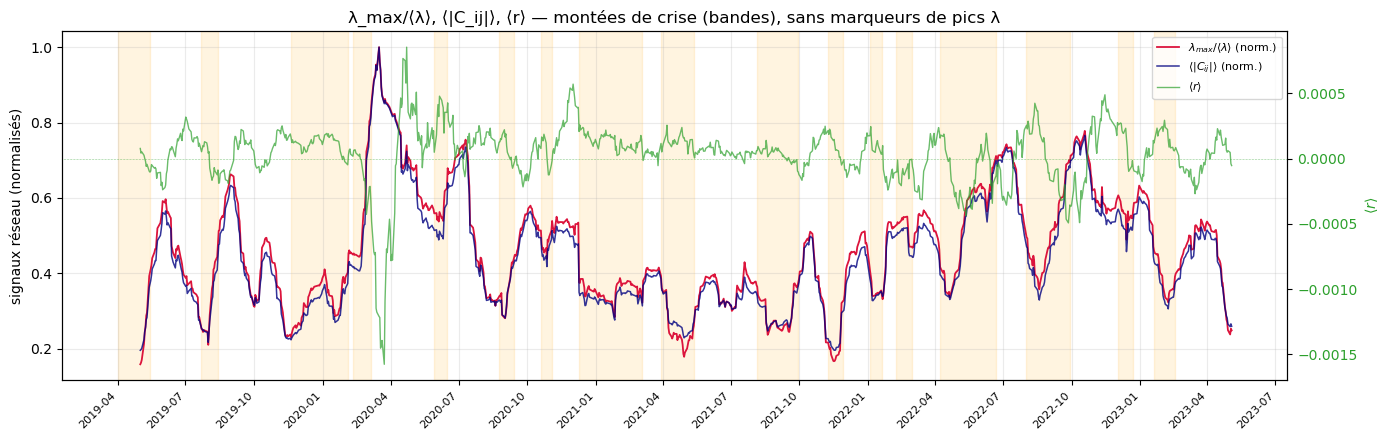

In [8]:
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(diag.index, diag['ratio_eig'] / np.nanmax(diag['ratio_eig']), color='crimson', lw=1.3,
        label=r'$\lambda_{max}/\langle\lambda\rangle$ (norm.)')
ax.plot(diag.index, diag['mean_corr'] / np.nanmax(diag['mean_corr']), color='navy', lw=1.1, alpha=0.8,
        label=r'$\langle|C_{ij}|\rangle$ (norm.)')
ax.set_ylabel('signaux réseau (normalisés)'); ax.grid(alpha=0.25)
axb = ax.twinx()
axb.plot(diag.index, diag['mean_return'], color='tab:green', lw=1.0, alpha=0.7, label=r'$\langle r\rangle$')
axb.axhline(0, color='tab:green', lw=0.4, ls=':'); axb.set_ylabel(r'$\langle r\rangle$', color='tab:green')
axb.tick_params(axis='y', labelcolor='tab:green')
for (pa, pb) in peak_rises:
    ax.axvspan(all_days[pa], all_days[pb], color='orange', alpha=0.12)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = axb.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc='upper right')
ax.set_title('λ_max/⟨λ⟩, ⟨|C_ij|⟩, ⟨r⟩ — montées de crise (bandes), sans marqueurs de pics λ')
plt.tight_layout(); plt.show()

### Superposition clustering + signaux réseau

Le clustering lissé (normalisé) superposé à λ_max/⟨λ⟩ et ⟨|C_ij|⟩ (normalisés) sur l'axe gauche, ⟨r⟩ sur l'axe droit — pour comparer leurs montées sur les bandes de crise.

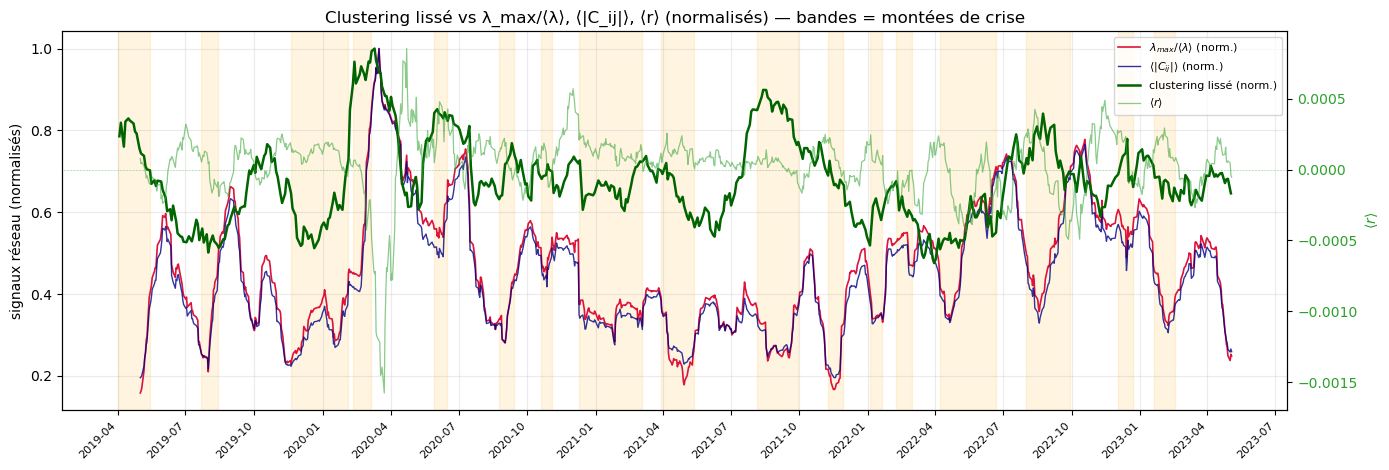

In [9]:
# Superposition : clustering lissé + λ_max/⟨λ⟩ + ⟨|C|⟩ (normalisés), ⟨r⟩ à droite
fig, ax = plt.subplots(figsize=(14, 4.8))
ax.plot(diag.index, diag['ratio_eig'] / np.nanmax(diag['ratio_eig']), color='crimson', lw=1.2,
        label=r'$\lambda_{max}/\langle\lambda\rangle$ (norm.)')
ax.plot(diag.index, diag['mean_corr'] / np.nanmax(diag['mean_corr']), color='navy', lw=1.0, alpha=0.8,
        label=r'$\langle|C_{ij}|\rangle$ (norm.)')
ax.plot(cdates, clus_s / np.nanmax(clus_s), color='darkgreen', lw=1.8,
        label='clustering lissé (norm.)')
ax.set_ylabel('signaux réseau (normalisés)'); ax.grid(alpha=0.25)
axb = ax.twinx()
axb.plot(diag.index, diag['mean_return'], color='tab:green', lw=0.9, alpha=0.55, label=r'$\langle r\rangle$')
axb.axhline(0, color='tab:green', lw=0.4, ls=':'); axb.set_ylabel(r'$\langle r\rangle$', color='tab:green')
axb.tick_params(axis='y', labelcolor='tab:green')
for (pa, pb) in peak_rises:
    ax.axvspan(all_days[pa], all_days[pb], color='orange', alpha=0.12)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = axb.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc='upper right')
ax.set_title('Clustering lissé vs λ_max/⟨λ⟩, ⟨|C_ij|⟩, ⟨r⟩ (normalisés) — bandes = montées de crise')
plt.tight_layout(); plt.show()

## 3. Balayage (B, R) — méthode des pics

Les actifs retenus (fit SIS R² > seuil sur les montées de pics) bougent-ils quand on change les taux SIS **B** (récupération) et **R** (infection) ? On compare les **ensembles** d'actifs retenus à 5 points (B, R) : la référence (1, 1), les deux coins **diagonaux** (0.8, 0.8) / (1.2, 1.2) et les deux coins **hors-diagonale** (0.8, 1.2) / (1.2, 0.8).

> Calcul en cache (`br_sets_pk`) : réintégration SIS parallélisée sur les 17 montées (~2 min au 1er passage).

In [10]:
import os
from joblib import Parallel, delayed
from cache import disk_cache, sig_of

PTS = [(1.0, 1.0), (0.8, 0.8), (1.2, 1.2), (0.8, 1.2), (1.2, 0.8)]

# Référence B=R=1 : lue directement des fits déjà en cache (aucune intégration)
ref_sets = {m: set() for m in config.SIS_MODELS}
for (pa, pb) in peak_rises:
    fits = peak_pd[(pa, pb)][1]
    for m in config.SIS_MODELS:
        ref_sets[m] |= {gi for gi, sl in fits[m][1].items() if sl['r2'] > config.R2_SEUIL}

def _window_sets(cache, B, R):
    out = {m: set() for m in config.SIS_MODELS}
    for gi, d in cache.items():
        E_i = d['E_i']; ok = ~np.isnan(E_i)
        if ok.sum() < 3:
            continue
        for m in config.SIS_MODELS:
            xt = sis.integrate_fast(d, gi, ctx.A_sis[m], B=B, R=R)
            if linregress(E_i[ok], xt[ok]).rvalue ** 2 > config.R2_SEUIL:
                out[m].add(gi)
    return out

def _compute_br_sets():
    non_ref = [p for p in PTS if p != (1.0, 1.0)]
    tasks = [(p, (pa, pb)) for p in non_ref for (pa, pb) in peak_rises]
    parts = Parallel(n_jobs=min(len(tasks), os.cpu_count()))(
        delayed(_window_sets)(peak_pd[(pa, pb)][0], *p) for (p, (pa, pb)) in tasks)
    out = {p: {m: set() for m in config.SIS_MODELS} for p in non_ref}
    for (p, _), part in zip(tasks, parts):
        for m in config.SIS_MODELS:
            out[p][m] |= part[m]
    out[(1.0, 1.0)] = ref_sets
    return out

_sig = 'pk5_' + sig_of(repr(sorted(peak_rises)), repr(PTS), str(config.R2_SEUIL))
br_sets = disk_cache('br_sets_pk', _sig, _compute_br_sets)

[cache] OK  br_sets_pk


Nombre d'actifs retenus (R² > 0.6) par (B, R) et méthode :


,PMFG,VAR(1),VAR(13),Corr thr
"B=1.0,R=1.0",64,61,68,65
"B=0.8,R=0.8",64,61,68,65
"B=1.2,R=1.2",64,61,68,65
"B=0.8,R=1.2",66,64,71,65
"B=1.2,R=0.8",61,54,66,65



Identité des actifs vs référence B=R=1 :


,B,R,methode,n,communs,Jaccard,ajoutes,retires
0,0.8,0.8,PMFG,64,64,1.00,0,0
1,0.8,0.8,VAR(1),61,61,1.00,0,0
2,0.8,0.8,VAR(13),68,68,1.00,0,0
3,0.8,0.8,Corr thr,65,65,1.00,0,0
4,1.2,1.2,PMFG,64,64,1.00,0,0
5,1.2,1.2,VAR(1),61,61,1.00,0,0
6,1.2,1.2,VAR(13),68,68,1.00,0,0
7,1.2,1.2,Corr thr,65,65,1.00,0,0
8,0.8,1.2,PMFG,66,63,0.94,3,1
9,0.8,1.2,VAR(1),64,59,0.89,5,2


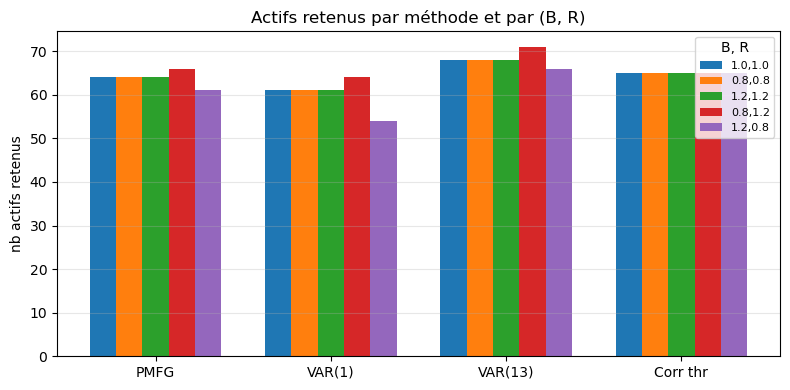

In [11]:
# Tableau : nb d'actifs retenus par méthode à chaque (B, R)
nA = pd.DataFrame({f'B={B},R={R}': {m: len(br_sets[(B, R)][m]) for m in config.SIS_MODELS}
                   for (B, R) in PTS}).T
print('Nombre d\'actifs retenus (R² > %.1f) par (B, R) et méthode :' % config.R2_SEUIL)
display(nA)

# Comparaison d'IDENTITÉ vs référence B=R=1 (Jaccard + ajoutés/retirés)
print('\nIdentité des actifs vs référence B=R=1 :')
rows = []
for (B, R) in PTS:
    if (B, R) == (1.0, 1.0):
        continue
    for m in config.SIS_MODELS:
        r, s = ref_sets[m], br_sets[(B, R)][m]
        jac = len(r & s) / max(1, len(r | s))
        rows.append({'B': B, 'R': R, 'methode': m, 'n': len(s), 'communs': len(r & s),
                     'Jaccard': round(jac, 2), 'ajoutes': len(s - r), 'retires': len(r - s)})
display(pd.DataFrame(rows))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(config.SIS_MODELS)); w = 0.15
for k, (B, R) in enumerate(PTS):
    ax.bar(x + (k - 2) * w, [len(br_sets[(B, R)][m]) for m in config.SIS_MODELS], w, label=f'{B},{R}')
ax.set_xticks(x); ax.set_xticklabels(config.SIS_MODELS); ax.set_ylabel('nb actifs retenus')
ax.legend(title='B, R', fontsize=8); ax.set_title('Actifs retenus par méthode et par (B, R)'); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

**Lecture.**
- **Diagonale** (0.8, 0.8) et (1.2, 1.2) : **exactement** les mêmes actifs que B=R=1 (Jaccard = 1.00). Multiplier B et R par le même facteur ne fait que **redilater le temps** de l'ODE SIS ; comme l'intégration recalibre T_conv sur l'équilibre, la forme de x_i(t) — donc le R² — est inchangée.
- **Hors-diagonale** (ratio R/B modifié) : churn **marginal** (Jaccard 0.89–0.96). Plus d'infection que de récupération (0.8, 1.2) ajoute quelques actifs ; l'inverse (1.2, 0.8) en retire quelques-uns.

**Conclusion : augmenter B et R *ensemble* ne change rien à la sélection** ; seul le **ratio R/B** compte, et il ne déplace qu'une poignée d'actifs en marge. Le cœur retenu est robuste.

## 4. Test null — le SIS marche-t-il **hors** crise collective ?

Pour chaque actif **retenu** (R² > 0.6 dans au moins une crise collective), on cherche une **montée individuelle de son E_i en dehors** de toutes les crises collectives (mêmes détecteurs : `asset_runs` sur la carte de crise, puis `strong_rise`), et on y ajuste le SIS. Si le modèle ne marche que sur les crises *collectives*, ces montées hors-crise doivent beaucoup moins bien s'ajuster.

> La construction de E_i / x0 reproduit **exactement** `cache_signed` (corrélations signées par jour) — validé contre les R² en cache. Fits mis en cache (`null_offcrisis`).

In [12]:
from cache import disk_cache, sig_of
from periods import asset_runs, strong_rise

def _build_entry(gi, a, b):
    # Entrée (E_i, x0, n_days) à la manière de cache_signed, sur le run (a, b) de gi.
    res = strong_rise(ctx.E_daily_all[gi, a:b + 1])
    if res is None:
        return None
    A0, B0 = a + res[2], a + res[3]
    days_p = list(ctx.all_days[A0:B0 + 1])
    dp = ctx.data[np.isin(ctx.data.index.date, days_p)].copy(); dp['day'] = dp.index.date
    days_s = sorted(dp['day'].unique()); n_days = len(days_s)
    Es = np.full((N, n_days), np.nan)
    for k, d in enumerate(days_s):
        chunk = dp[dp['day'] == d].drop(columns=['day']).values
        if len(chunk) < 3:
            continue
        C = np.nan_to_num(np.corrcoef(chunk.T), nan=0.0); np.fill_diagonal(C, 0)
        Es[:, k] = C.sum(axis=1) / (N - 1)
    valid = np.where(np.any(~np.isnan(Es), axis=0))[0]
    if len(valid) == 0:
        return None
    return dict(E_i=Es[gi], x0=Es[:, valid[0]], n_days=n_days)

def _overlaps_collective(a, b):
    return any(a <= pb and b >= pa for (pa, pb) in peak_rises)

# actifs retenus (union des méthodes) + leurs R² collectifs
selected = set()
coll_r2 = {m: [] for m in config.SIS_MODELS}
for (pa, pb) in peak_rises:
    for m in config.SIS_MODELS:
        for gi, sl in peak_pd[(pa, pb)][1][m][1].items():
            if sl['r2'] > config.R2_SEUIL:
                selected.add(gi)
for (pa, pb) in peak_rises:
    for m in config.SIS_MODELS:
        for gi, sl in peak_pd[(pa, pb)][1][m][1].items():
            if gi in selected:
                coll_r2[m].append(sl['r2'])

def _compute_null():
    null_r2 = {m: [] for m in config.SIS_MODELS}; wins = []
    for gi in sorted(selected):
        for (a, b) in asset_runs(crisis_map[gi]):
            if _overlaps_collective(a, b):
                continue
            d = _build_entry(gi, a, b)
            if d is None:
                continue
            E_i = d['E_i']; ok = ~np.isnan(E_i)
            if ok.sum() < 3:
                continue
            wins.append((gi, a, b))
            for m in config.SIS_MODELS:
                xt = sis.integrate(d, gi, ctx.A_sis[m])
                null_r2[m].append(linregress(E_i[ok], xt[ok]).rvalue ** 2)
    return dict(null_r2=null_r2, wins=wins)

_sig = 'off_' + sig_of(repr(sorted(selected)), repr(sorted(peak_rises)), str(config.R2_SEUIL))
null = disk_cache('null_offcrisis', _sig, _compute_null)
null_r2 = null['null_r2']
print(f'{len(selected)} actifs retenus  ->  {len(null["wins"])} montées individuelles hors crise collective')

[cache] OK  null_offcrisis
72 actifs retenus  ->  35 montées individuelles hors crise collective


,methode,coll_n,coll_%>0.6,coll_med,horsCrise_n,horsCrise_%>0.6,horsCrise_med
0,PMFG,395,18.5,0.256,35,8.6,0.337
1,VAR(1),395,18.0,0.248,35,5.7,0.344
2,VAR(13),395,20.0,0.261,35,8.6,0.343
3,Corr thr,395,19.0,0.263,35,8.6,0.336


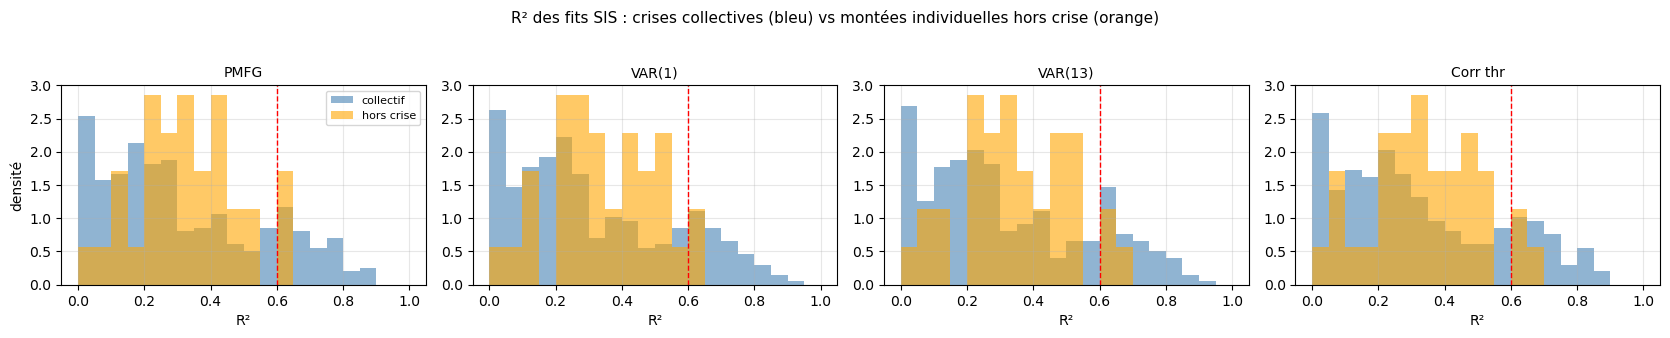

In [13]:
# Tableau comparatif collectif vs hors-crise
rows = []
for m in config.SIS_MODELS:
    c = np.array(coll_r2[m]); nc = np.array(null_r2[m])
    rows.append({'methode': m, 'coll_n': len(c), 'coll_%>0.6': round(100 * np.mean(c > config.R2_SEUIL), 1),
                 'coll_med': round(float(np.median(c)), 3), 'horsCrise_n': len(nc),
                 'horsCrise_%>0.6': round(100 * np.mean(nc > config.R2_SEUIL), 1),
                 'horsCrise_med': round(float(np.median(nc)), 3)})
display(pd.DataFrame(rows))

fig, axes = plt.subplots(1, len(config.SIS_MODELS), figsize=(4.2 * len(config.SIS_MODELS), 3.4), squeeze=False)
for j, m in enumerate(config.SIS_MODELS):
    ax = axes[0, j]
    ax.hist(coll_r2[m], bins=np.linspace(0, 1, 21), density=True, color='steelblue', alpha=0.6, label='collectif')
    ax.hist(null_r2[m], bins=np.linspace(0, 1, 21), density=True, color='orange', alpha=0.6, label='hors crise')
    ax.axvline(config.R2_SEUIL, color='red', ls='--', lw=1)
    ax.set_title(m, fontsize=10); ax.set_xlabel('R²'); ax.grid(alpha=0.3)
    if j == 0:
        ax.set_ylabel('densité'); ax.legend(fontsize=8)
plt.suptitle('R² des fits SIS : crises collectives (bleu) vs montées individuelles hors crise (orange)', fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

**Lecture.** Hors des crises collectives, on ne trouve que **~35 montées individuelles** propres (sur 72 actifs retenus, ~380 plages hors-crise) : déjà un signe que la montée nette de E_i est surtout un phénomène **collectif**. Sur ces montées, la part de bons fits (R² > 0.6) tombe à **~6–9 %**, contre **~18–20 %** en crise collective (≈ 2–3× moins). La médiane des R² reste comparable : l'effet porte sur la **queue** (les très bons fits), pas sur le centre. **Conclusion : le SIS ajuste nettement mieux les crises collectives, sans être totalement spécifique** — une partie du « bon fit » reste l'artefact montante-vs-montante (cf. nulls par permutation).

## 5. Actifs retenus par méthode × période + accord entre méthodes

Nombre d'actifs retenus (fit SIS R² > 0.6) **par période de crise et par méthode** de contagion (PMFG, VAR(1), VAR(13), Corr thr), plus l'**union**, le nb d'actifs retenus par **toutes** les méthodes et le **% commun** (intersection / union). On regarde si les 4 méthodes désignent les mêmes actifs.

,periode,PMFG,VAR(1),VAR(13),Corr thr,union,communs,%commun
0,2019-04-01 → 2019-05-15,14,13,16,16,18,11,61.1
1,2019-07-22 → 2019-08-14,5,5,5,5,5,5,100.0
2,2020-02-11 → 2020-03-06,44,42,46,44,48,38,79.2
3,2020-05-29 → 2020-06-16,5,5,5,5,6,4,66.7
4,2022-01-03 → 2022-01-20,0,2,2,0,2,0,0.0
5,2022-02-08 → 2022-03-01,1,0,0,1,1,0,0.0
6,2022-04-08 → 2022-06-22,4,4,5,4,5,4,80.0


GLOBAL (toutes périodes confondues) :
  PMFG       : 64 actifs retenus
  VAR(1)     : 61 actifs retenus
  VAR(13)    : 68 actifs retenus
  Corr thr   : 65 actifs retenus
  communs aux 4 méthodes : 54 / 72 (union) = 75 %


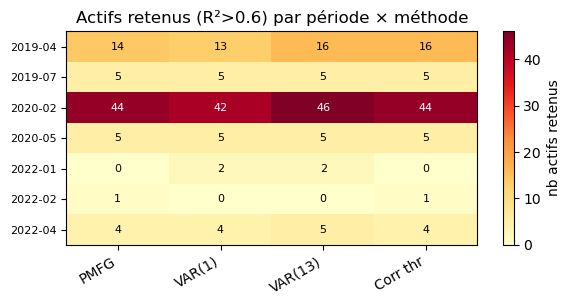

In [14]:
# Ensembles retenus par (période, méthode)
sel_pm = {}
for (pa, pb) in peak_rises:
    sel_pm[(pa, pb)] = {m: {gi for gi, sl in peak_pd[(pa, pb)][1][m][1].items() if sl['r2'] > config.R2_SEUIL}
                        for m in config.SIS_MODELS}

# on ne garde que les périodes avec au moins un actif retenu (on enlève les zéros partout)
kept = [(pa, pb) for (pa, pb) in peak_rises if set().union(*sel_pm[(pa, pb)].values())]

rows = []
for (pa, pb) in kept:
    s = sel_pm[(pa, pb)]; union = set().union(*s.values())
    # commun = actifs retenus par les 4 méthodes À LA FOIS (intersection)
    inter = set.intersection(*s.values()) if all(s.values()) else set()
    row = {'periode': f'{str(all_days[pa])[:10]} → {str(all_days[pb])[:10]}'}
    for m in config.SIS_MODELS:
        row[m] = len(s[m])
    row['union'] = len(union); row['communs'] = len(inter)
    row['%commun'] = round(100 * len(inter) / max(1, len(union)), 1)
    rows.append(row)
tab5 = pd.DataFrame(rows)
display(tab5)

# Global : union sur toutes les périodes
allsel = {m: set().union(*(sel_pm[w][m] for w in peak_rises)) for m in config.SIS_MODELS}
inter = set.intersection(*allsel.values()); union = set().union(*allsel.values())
print('GLOBAL (toutes périodes confondues) :')
for m in config.SIS_MODELS:
    print(f'  {m:10s} : {len(allsel[m])} actifs retenus')
print(f'  communs aux 4 méthodes : {len(inter)} / {len(union)} (union) = '
      f'{100*len(inter)/len(union):.0f} %')

# Heatmap période × méthode (périodes non vides seulement)
import numpy as _np
M = _np.array([[len(sel_pm[(pa, pb)][m]) for m in config.SIS_MODELS] for (pa, pb) in kept])
fig, ax = plt.subplots(figsize=(6, max(2.5, 0.45 * len(kept))))
im = ax.imshow(M, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(config.SIS_MODELS))); ax.set_xticklabels(config.SIS_MODELS, rotation=30, ha='right')
ax.set_yticks(range(len(kept)))
ax.set_yticklabels([f'{str(all_days[pa])[:7]}' for (pa, pb) in kept], fontsize=8)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, M[i, j], ha='center', va='center', fontsize=8,
                color='black' if M[i, j] < M.max() * 0.6 else 'white')
fig.colorbar(im, ax=ax, label='nb actifs retenus'); ax.set_title('Actifs retenus (R²>0.6) par période × méthode')
plt.tight_layout(); plt.show()

**Lecture.** Les actifs retenus se concentrent dans les **grandes crises collectives** (COVID fév.–mars 2020 : 44–46 par méthode ; avril 2019 : 14–16 ; mai 2020 / avril–juin 2022 : ~5). Beaucoup de montées n'en retiennent **aucun**. Surtout, les 4 méthodes désignent **largement les mêmes actifs** : là où il y a des retenus, le % commun est de 60–100 %, et **globalement ~75 % des actifs retenus le sont par les 4 méthodes**. Le choix de la matrice de contagion (PMFG, VAR, Corr thr) ne change donc presque pas *quels* actifs sont expliqués par le SIS.

## 6. Communautés (Louvain) — les actifs en crise sont-ils regroupés ?

Pour chaque période de crise, on construit le **réseau de corrélations de la période** (méthode `Corr thr`, top 15 % des |C_ij| → graphe connexe), on détecte les **communautés par Louvain**, et on regarde si les **actifs en crise** (détectés sur la période) tombent dans **une même communauté**.

Métrique : part des actifs en crise dans leur communauté **dominante**, comparée à un **tirage aléatoire** d'actifs de même taille (200 tirages). Si crise ≈ aléatoire → pas de regroupement particulier.

In [15]:
from networks import build_filtered_corr
from collections import Counter

def _period_graph(pa, pb):
    obs = (ctx.data.index >= all_days[pa]) & (ctx.data.index <= all_days[pb])
    C = np.abs(np.nan_to_num(np.corrcoef(arr[np.asarray(obs)].T))); np.fill_diagonal(C, 0)
    A = build_filtered_corr(C, config.CORR_THRESHOLD, ctx.mask_off)
    return nx.from_numpy_array(A)

def _louvain_concentration(pa, pb, n_rand=200):
    crisis = set(peak_pd[(pa, pb)][0])
    G = _period_graph(pa, pb)
    comm = nx.community.louvain_communities(G, weight='weight', seed=0)
    n2c = {n: ci for ci, c in enumerate(comm) for n in c}
    mod = nx.community.modularity(G, comm, weight='weight')
    dom = Counter(n2c[g] for g in crisis).most_common(1)[0][1] if crisis else 0
    rng = np.random.default_rng(0)
    rand = [Counter(n2c[s] for s in rng.choice(N, len(crisis), replace=False)).most_common(1)[0][1]
            for _ in range(n_rand)] if crisis else [0]
    return G, comm, n2c, mod, 100 * dom / max(1, len(crisis)), 100 * np.mean(rand) / max(1, len(crisis))

rows = []
big = [(pa, pb) for (pa, pb) in peak_rises if len(peak_pd[(pa, pb)][0]) >= 20]
for (pa, pb) in big:
    _, comm, _, mod, pct, randp = _louvain_concentration(pa, pb)
    rows.append({'periode': f'{str(all_days[pa])[:10]} → {str(all_days[pb])[:10]}',
                 'n_crise': len(peak_pd[(pa, pb)][0]), 'n_comm': len(comm), 'modularite': round(mod, 2),
                 '%crise_dominante': round(pct, 0), '%aleatoire': round(randp, 0),
                 'exces': round(pct - randp, 0)})
tab6 = pd.DataFrame(rows)
display(tab6)
print(f"Excès moyen (crise - aléatoire) : {tab6['exces'].mean():+.1f} points de %")

,periode,n_crise,n_comm,modularite,%crise_dominante,%aleatoire,exces
0,2019-04-01 → 2019-05-15,73,11,0.27,34.0,30.0,4.0
1,2019-07-22 → 2019-08-14,38,27,0.15,39.0,33.0,6.0
2,2020-02-11 → 2020-03-06,139,25,0.26,31.0,31.0,0.0
3,2020-05-29 → 2020-06-16,94,36,0.18,31.0,32.0,-1.0
4,2020-10-19 → 2020-11-04,25,21,0.28,36.0,37.0,-1.0
5,2021-08-05 → 2021-09-29,37,8,0.44,51.0,41.0,10.0
6,2021-11-09 → 2021-11-29,34,23,0.19,32.0,30.0,2.0
7,2022-01-03 → 2022-01-20,92,4,0.41,32.0,30.0,1.0
8,2022-04-08 → 2022-06-22,65,20,0.23,32.0,29.0,4.0
9,2022-08-01 → 2022-09-29,78,18,0.28,38.0,29.0,9.0


Excès moyen (crise - aléatoire) : +3.5 points de %


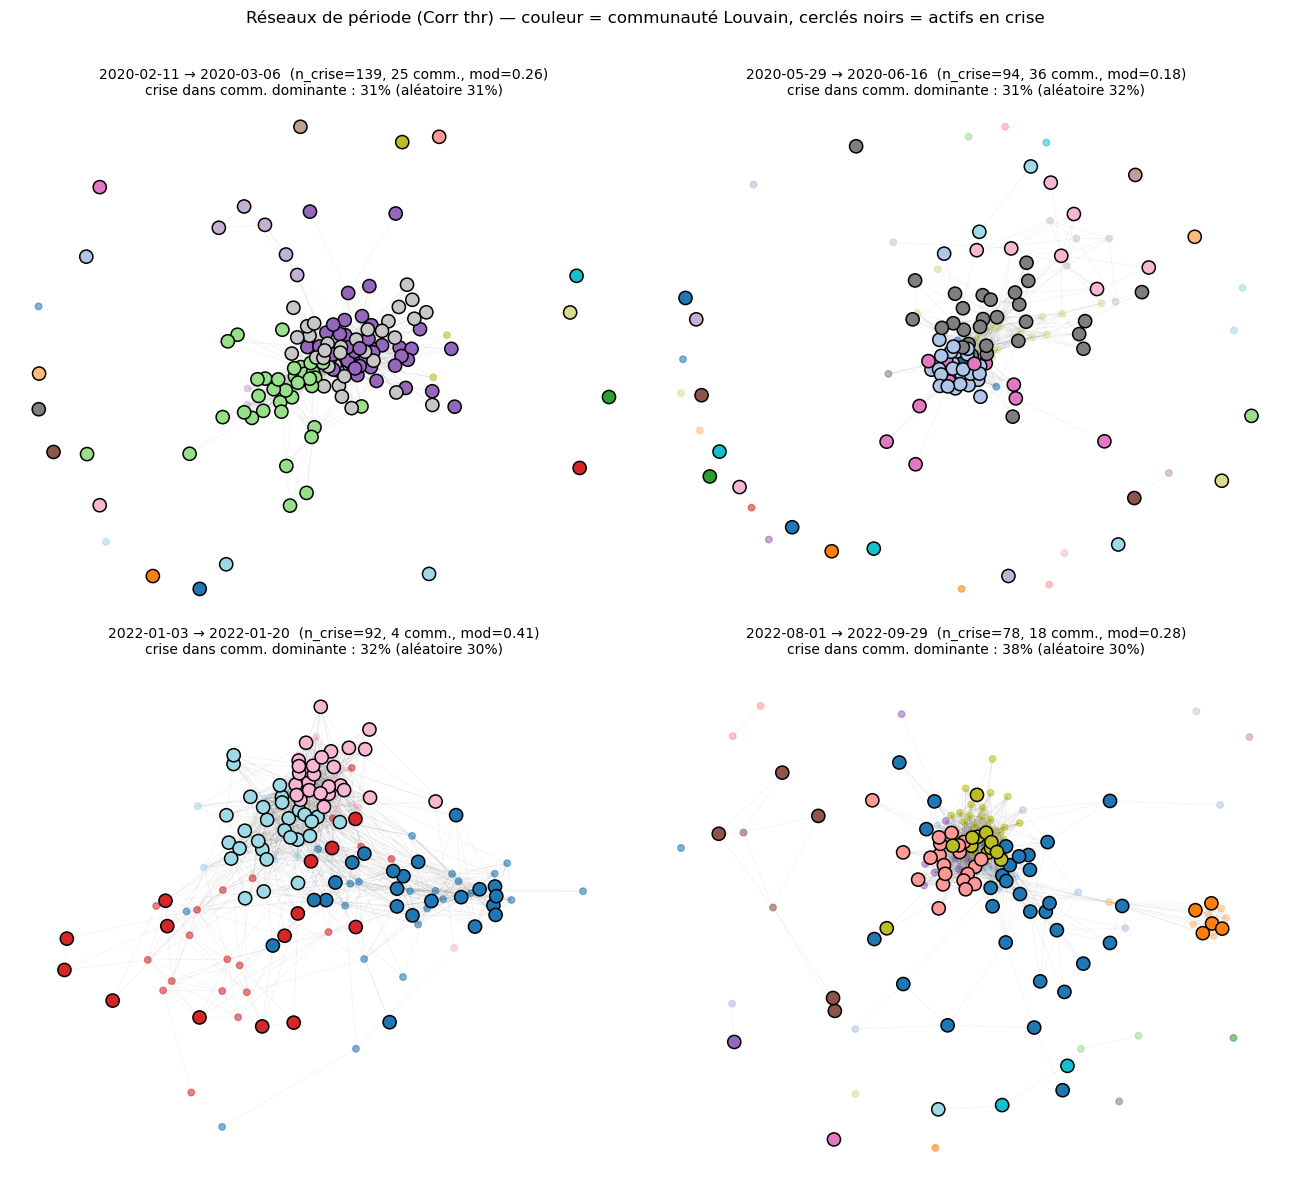

In [16]:
# Graphes de 4 grandes crises : couleur = communauté Louvain, actifs en crise cerclés de noir
import matplotlib.cm as cm
sel4 = sorted(big, key=lambda w: -len(peak_pd[w][0]))[:4]
fig, axes = plt.subplots(2, 2, figsize=(13, 12))
for ax, (pa, pb) in zip(axes.ravel(), sel4):
    crisis = set(peak_pd[(pa, pb)][0])
    G, comm, n2c, mod, pct, randp = _louvain_concentration(pa, pb, n_rand=50)
    pos = nx.spring_layout(G, seed=1, k=0.25)
    colors = [n2c[n] for n in G.nodes()]
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.06, width=0.5)
    nc = [n for n in G.nodes() if n not in crisis]
    cc = [n for n in G.nodes() if n in crisis]
    nx.draw_networkx_nodes(G, pos, nodelist=nc, node_color=[n2c[n] for n in nc], cmap='tab20',
                           node_size=22, ax=ax, alpha=0.55)
    nx.draw_networkx_nodes(G, pos, nodelist=cc, node_color=[n2c[n] for n in cc], cmap='tab20',
                           node_size=90, edgecolors='black', linewidths=1.1, ax=ax)
    ax.set_title(f'{str(all_days[pa])[:10]} → {str(all_days[pb])[:10]}  '
                 f'(n_crise={len(crisis)}, {len(comm)} comm., mod={mod:.2f})\n'
                 f'crise dans comm. dominante : {pct:.0f}% (aléatoire {randp:.0f}%)', fontsize=10)
    ax.axis('off')
plt.suptitle('Réseaux de période (Corr thr) — couleur = communauté Louvain, '
             'cerclés noirs = actifs en crise', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

**Lecture.** Les actifs en crise se retrouvent dans leur communauté dominante à ~**30–50 %**, mais un **tirage aléatoire** de même taille atteint déjà ~**30–40 %** (la communauté dominante est simplement grosse). L'**excès crise − aléatoire est quasi nul** (quelques points de % au plus). **Conclusion : les actifs en crise ne forment pas une communauté commune** — une crise collective traverse les communautés (phénomène **systémique**, inter-secteurs), elle n'est pas confinée à un cluster du réseau de corrélations.